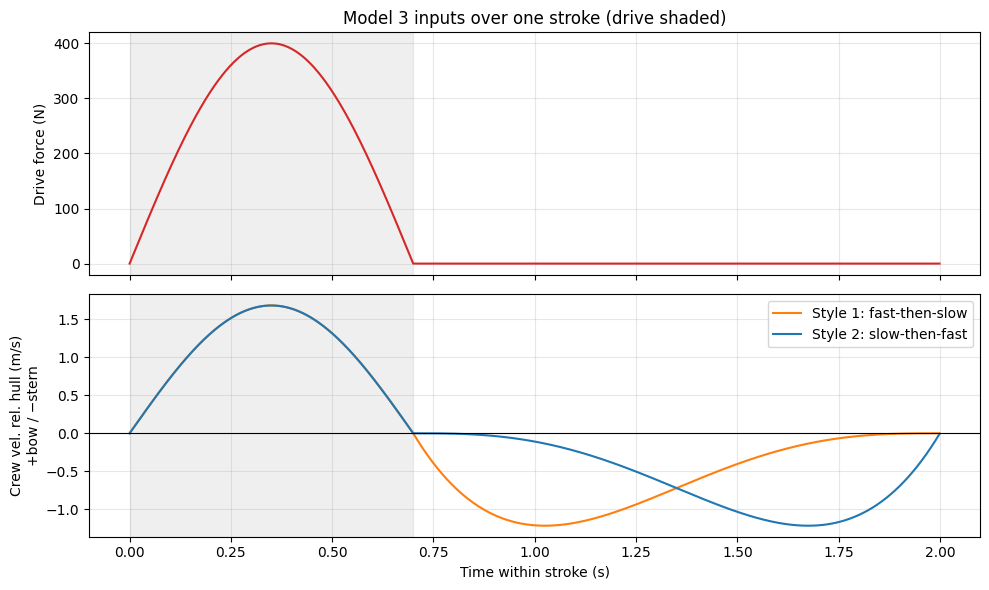

Style 1: drive +0.750 m, recovery -0.750 m
Style 2: drive +0.750 m, recovery -0.750 m


In [1]:
# ============================================================
# Model 3: two-body (hull + crew), drag acts on HULL velocity.
# Question: at fixed impulse, rate, and slide length, does the
# SHAPE of the recovery (style 1 vs style 2) change mean speed?
# Convention: positive = bow (forward). Crew slides bowward in
# the drive (u>0), sternward in recovery (u<0).
# NOTE: this first version brings the crew to rest at the catch
# for BOTH styles — i.e. it deliberately EXCLUDES the catch-check.
# We add the check next, once the pure recovery effect is clear.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- Masses (Dudhia: crew ~80% of total) ---
m_crew  = 80.0
m_hull  = 20.0
M_total = m_crew + m_hull
mass_ratio = m_crew / M_total      # 0.8 — the coupling strength

# --- Drive force, timing, drag (same lineage as Models 1-2) ---
F_max      = 400.0
t_drive    = 0.7
t_recovery = 1.3
t_stroke   = t_drive + t_recovery
dt         = 0.001
n_strokes  = 20
a_drag     = 3.0                   # validated single-sculler value
L_slide    = 0.75                  # crew travel relative to hull, m

# --- Build templates over ONE stroke ---
t_one = np.arange(0, t_stroke, dt)

# Drive force: sine pulse in the drive, zero in recovery
F_template = np.where(t_one < t_drive,
                      F_max * np.sin(np.pi * t_one / t_drive), 0.0)

def crew_velocity_template(p, q):
    """Crew velocity relative to hull over one stroke.
    Drive = bowward half-sine (+L_slide). Recovery = sternward
    hump skewed by (p,q), normalised to exactly -L_slide."""
    u = np.zeros_like(t_one)
    drive = t_one < t_drive
    rec   = ~drive

    ds = np.sin(np.pi * t_one[drive] / t_drive)
    u[drive] = (L_slide / (ds.sum() * dt)) * ds          # +L_slide

    x  = (t_one[rec] - t_drive) / t_recovery             # 0..1
    rs = x**(p-1) * (1 - x)**(q-1)                        # skew shape
    u[rec] = -(L_slide / (rs.sum() * dt)) * rs           # -L_slide
    return u

# The TWO styles differ ONLY in recovery shape:
u_style1 = crew_velocity_template(2, 4)   # front-loaded: fast-then-slow
u_style2 = crew_velocity_template(4, 2)   # back-loaded:  slow-then-fast

# --- Verify inputs BEFORE simulating ---
fig, (axF, axU) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axF.plot(t_one, F_template, color="tab:red")
axF.axvspan(0, t_drive, color="grey", alpha=0.12)
axF.set_ylabel("Drive force (N)"); axF.grid(True, alpha=0.3)
axF.set_title("Model 3 inputs over one stroke (drive shaded)")

axU.plot(t_one, u_style1, color="tab:orange", label="Style 1: fast-then-slow")
axU.plot(t_one, u_style2, color="tab:blue",   label="Style 2: slow-then-fast")
axU.axhline(0, color="black", lw=0.8)
axU.axvspan(0, t_drive, color="grey", alpha=0.12)
axU.set_ylabel("Crew vel. rel. hull (m/s)\n+bow / −stern")
axU.set_xlabel("Time within stroke (s)")
axU.legend(loc="upper right"); axU.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Sanity: both styles must move the SAME slide length each phase
for name, u in [("Style 1", u_style1), ("Style 2", u_style2)]:
    print(f"{name}: drive {(u[t_one<t_drive].sum()*dt):+.3f} m, "
          f"recovery {(u[t_one>=t_drive].sum()*dt):+.3f} m")

In [2]:
# --- Cell 2: two-body engine. Drag acts on the HULL. ---
def simulate(u_template, n_strokes=n_strokes):
    """Run the two-body model for a given recovery style.
    Returns time, hull velocity, and COM velocity arrays."""
    # Tile the one-stroke templates out to n_strokes
    F = np.tile(F_template, n_strokes)
    u = np.tile(u_template, n_strokes)
    times = np.arange(0, len(F)) * dt

    v_cm   = 0.0                      # centre-of-mass velocity
    v_hull = np.zeros_like(times)     # what drag actually sees
    v_com  = np.zeros_like(times)

    for i in range(len(times)):
        # Hull velocity from momentum coupling (the heart of it):
        vh = v_cm - mass_ratio * u[i]

        # Drag acts on the HULL speed, not the COM:
        drag = -a_drag * vh * abs(vh)

        # External forces (drive + drag) move the WHOLE system COM:
        net = F[i] + drag
        v_cm = v_cm + (net / M_total) * dt

        v_hull[i] = vh
        v_com[i]  = v_cm
    return times, v_hull, v_com

# Run both styles
t1, vh1, vc1 = simulate(u_style1)
t2, vh2, vc2 = simulate(u_style2)

# Compare mean HULL speed over the final stroke (steady state)
last = slice(-len(t_one), None)
mean1 = vh1[last].mean()
mean2 = vh2[last].mean()

print(f"Style 1 (fast-then-slow): mean hull speed = {mean1:.4f} m/s")
print(f"Style 2 (slow-then-fast): mean hull speed = {mean2:.4f} m/s")
print(f"Difference: {(mean2-mean1):+.4f} m/s "
      f"({100*(mean2-mean1)/mean1:+.2f}%)")

Style 1 (fast-then-slow): mean hull speed = 5.3779 m/s
Style 2 (slow-then-fast): mean hull speed = 5.3987 m/s
Difference: +0.0208 m/s (+0.39%)


In [3]:
# --- Cell 3: convert steady-state speed into a 700m course result ---
distance_home = 700.0   # your home course, metres

def course_time(mean_speed, distance):
    return distance / mean_speed

t1_home = course_time(mean1, distance_home)
t2_home = course_time(mean2, distance_home)
gap_home = t1_home - t2_home          # +ve => style 2 finishes first

# A boat length for a single scull ~ 8.2 m; gap in lengths = gap_dist / 8.2
boat_length = 8.2
gap_distance_home = mean2 * gap_home  # how far ahead style 2 is at the line

print(f"Over {distance_home:.0f} m at steady state:")
print(f"  Style 1: {t1_home:.2f} s")
print(f"  Style 2: {t2_home:.2f} s")
print(f"  Style 2 wins by {gap_home:.2f} s "
      f"= {gap_distance_home:.2f} m = {gap_distance_home/boat_length:.2f} boat lengths\n")

# Bonus: how the margin compounds with distance (it scales linearly)
print("Margin to style 2 by distance:")
for d in [500, 700, 1000, 2000]:
    g = d/mean1 - d/mean2
    print(f"  {d:>4d} m : {g:+.2f} s  ({mean2*g/boat_length:+.2f} lengths)")

Over 700 m at steady state:
  Style 1: 130.16 s
  Style 2: 129.66 s
  Style 2 wins by 0.50 s = 2.71 m = 0.33 boat lengths

Margin to style 2 by distance:
   500 m : +0.36 s  (+0.24 lengths)
   700 m : +0.50 s  (+0.33 lengths)
  1000 m : +0.72 s  (+0.47 lengths)
  2000 m : +1.43 s  (+0.94 lengths)
